Daily Challenge: Interactive Data Visualization with Matplotlib and Seaborn


👩‍🏫 👩🏿‍🏫 What You’ll learn
Advanced data visualization techniques.
Interactive chart creation using Matplotlib.
Elegant static data presentation with Seaborn.


Your Task


1. Data Preparation:
Download and explore the US Superstore data.
Perform basic data cleaning and preprocessing.


2. Data Visualization with Matplotlib:
Create an interactive line chart to show sales trends over the years.
Build an interactive map to visualize sales distribution by country.


3. Data Visualization with Seaborn:
Use Seaborn to generate a bar chart showing top 10 products by sales.
Create a scatter plot to analyze the relationship between profit and discount.


4. Comparative Analysis:
Compare the insights gained from Matplotlib and Seaborn visualizations.
Document your observations about the ease of use and effectiveness of both tools.


5. Code and Insights:
Write clear, well-documented Python code.
Include your analysis and insights as comments or markdown cells in your Jupyter notebook.




1. Data Preparation:
Download and explore the US Superstore data.
Perform basic data cleaning and preprocessing.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('US Superstore data.xls') # Loading the data frame from Excel file

# Exploring the data frame, this shows that there are no missing entries.

print("Shape:", df.shape)
print("\nFirst rows:\n", df.head())
print("\nInfo:\n", df.info())
print("\nMissing values:\n", df.isnull().sum())

# Check for duplicate rows, no duplicate rows found.

print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()


Shape: (9994, 21)

First rows:
    Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \


2. Data Visualization with Matplotlib:
Create an interactive line chart to show sales trends over the years.
Build an interactive map to visualize sales distribution by country.

Unique years in the data:
[np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]

Unique countries:
<StringArray>
['United States']
Length: 1, dtype: str

Sample data with Year column:
  Order Date  Year     Sales        Country
0 2016-11-08  2016  261.9600  United States
1 2016-11-08  2016  731.9400  United States
2 2016-06-12  2016   14.6200  United States
3 2015-10-11  2015  957.5775  United States
4 2015-10-11  2015   22.3680  United States
5 2014-06-09  2014   48.8600  United States
6 2014-06-09  2014    7.2800  United States
7 2014-06-09  2014  907.1520  United States
8 2014-06-09  2014   18.5040  United States
9 2014-06-09  2014  114.9000  United States
Sales by Year:
Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

Summary by Year:
   Year        Sales      Profit  Quantity
0  2014  484247.4981  49543.9741      7581
1  2015  470532.5090  61618.6037      7979
2  2016  609205.5980  81795.1743      9837
3  

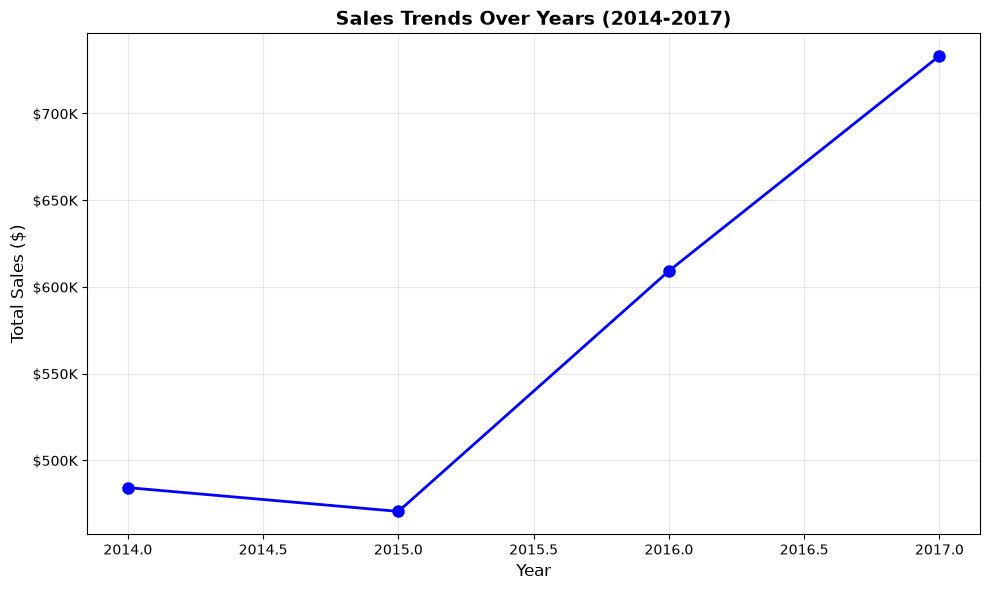

Top 10 States by Sales:
           State        Sales      Profit  Orders
3     California  457687.6315  76381.3871    2001
30      New York  310876.2710  74038.5486    1128
41         Texas  170188.0458 -25729.3563     985
45    Washington  138641.2700  33402.6517     506
36  Pennsylvania  116511.9140 -15559.9603     587
8        Florida   89473.7080  -3399.3017     383
11      Illinois   80166.1010 -12607.8870     492
33          Ohio   78258.1360 -16971.3766     469
20      Michigan   76269.6140  24463.1876     255
44      Virginia   70636.7200  18597.9504     224

Total states: 49


In [8]:
# Extract the year from the Order Date column
df['Year'] = df['Order Date'].dt.year

# Check what years we have
print("Unique years in the data:")
print(sorted(df['Year'].unique()))
print()

# Check what countries we have
print("Unique countries:")
print(df['Country'].unique())
print()

# Let's see a sample of the data with the new Year column
print("Sample data with Year column:")
print(df[['Order Date', 'Year', 'Sales', 'Country']].head(10))

# Group data by Year and sum the Sales
sales_by_year = df.groupby('Year')['Sales'].sum()

print("Sales by Year:")
print(sales_by_year)
print()

# Also let's see it as a nice table
sales_df = df.groupby('Year').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

print("Summary by Year:")
print(sales_df)

import matplotlib.pyplot as plt

# Create the line chart
plt.figure(figsize=(10, 6))
plt.plot(sales_df['Year'], sales_df['Sales'], marker='o', linewidth=2, markersize=8, color='blue')

# Add labels and title
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.title('Sales Trends Over Years (2014-2017)', fontsize=14, fontweight='bold')

# Add grid for easier reading
plt.grid(True, alpha=0.3)

# Format y-axis to show dollar amounts nicely
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Show the plot
plt.tight_layout()
plt.show()

# Group data by State and sum the Sales
sales_by_state = df.groupby('State').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'count'  # count of orders
}).reset_index()

# Rename the 'Order ID' column to 'Orders' for clarity
sales_by_state = sales_by_state.rename(columns={'Order ID': 'Orders'})

# Sort by sales (highest first)
sales_by_state = sales_by_state.sort_values('Sales', ascending=False)

print("Top 10 States by Sales:")
print(sales_by_state.head(10))
print()
print(f"Total states: {len(sales_by_state)}")

In [11]:
import plotly.graph_objects as go

# Create an interactive choropleth map (states colored by sales)
fig = go.Figure(data=go.Choropleth(
    locations = sales_by_state['State'],
    z = sales_by_state['Sales'],
    locationmode = 'USA-states',
    colorscale = 'Viridis',
    text = sales_by_state['State'],
    colorbar_title = "Total Sales ($)",
    hovertemplate = '<b>%{text}</b><br>Sales: $%{z:,.0f}<extra></extra>'
))

# Update layout
fig.update_layout(
    title_text = 'Total Sales by State (2014-2017)',
    geo_scope = 'usa',
    title_font_size = 16,
    height = 600,
    width = 1000
)

# Show the map
fig.show()

Top 10 Products

In [13]:
# Group by Product Name and sum the Sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

print("Top 10 Products by Sales:")
print(top_products)
print()

# Create a dataframe for easier plotting
top_products_df = top_products.reset_index()
print(top_products_df)

# Group by Product Name and sum the Sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

print("Top 10 Products by Sales:")
print(top_products)

Top 10 Products by Sales:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

                                        Pr

C:\Users\roche\AppData\Local\Temp\ipykernel_25888\2189678309.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products_df, y='Product Name', x='Sales', palette='viridis')


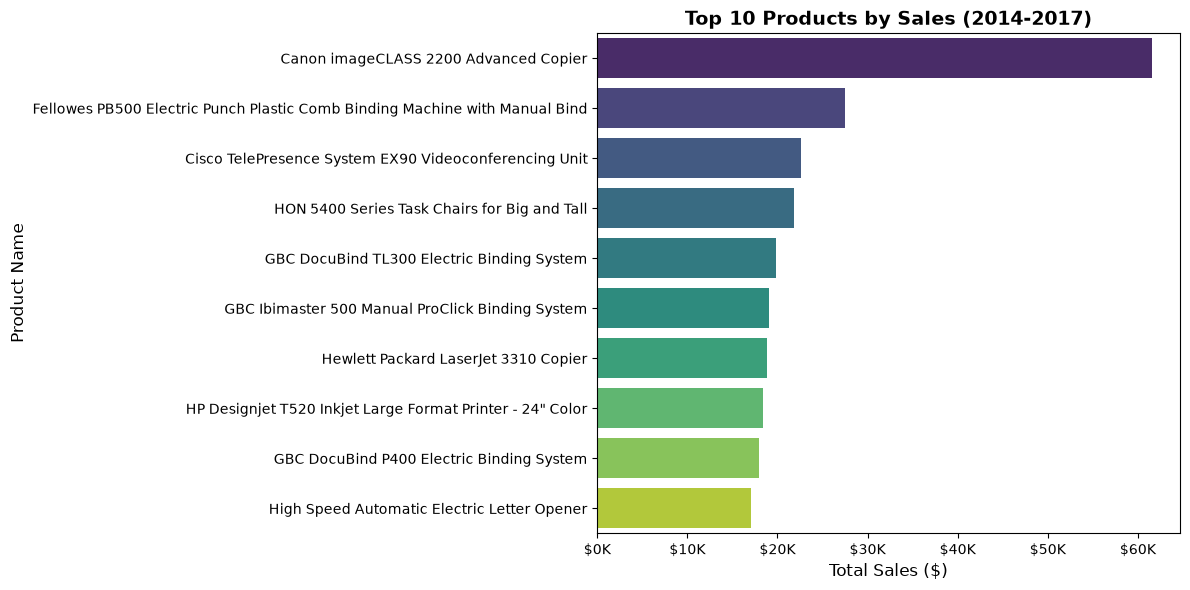

In [14]:
import seaborn as sns

# Create a dataframe with top 10 products (if you haven't already)
top_products_df = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

# Create the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=top_products_df, y='Product Name', x='Sales', palette='viridis')

# Add labels and title
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.title('Top 10 Products by Sales (2014-2017)', fontsize=14, fontweight='bold')

# Format x-axis to show dollar amounts
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Adjust layout so product names aren't cut off
plt.tight_layout()
plt.show()

Scatterplot

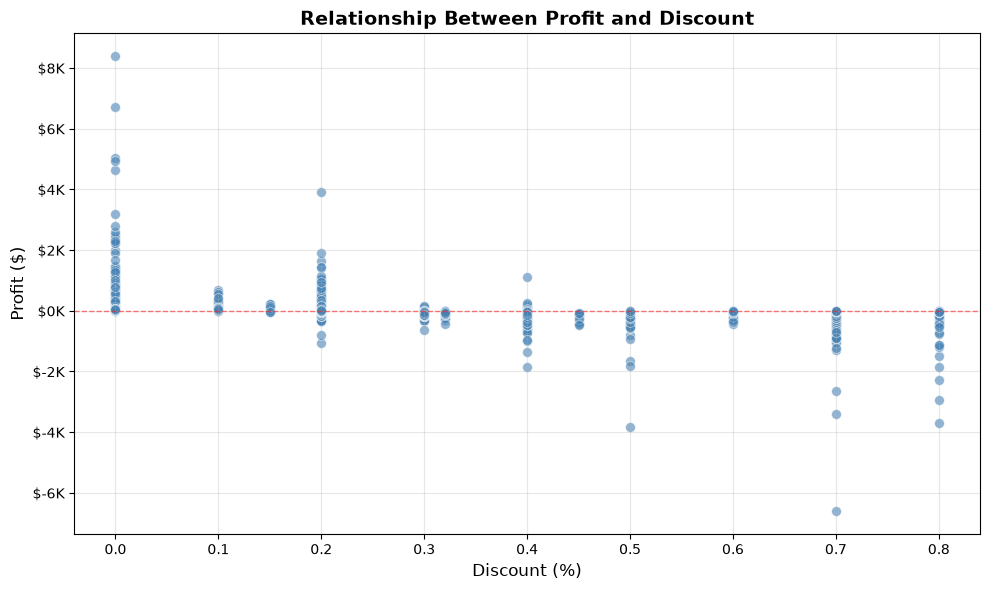

In [15]:
# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.6, s=50, color='steelblue')

# Add labels and title
plt.xlabel('Discount (%)', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.title('Relationship Between Profit and Discount', fontsize=14, fontweight='bold')

# Add a horizontal line at 0 profit (break-even)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Add grid for easier reading
plt.grid(True, alpha=0.3)

# Format y-axis to show dollar amounts
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()